# Mixed-Field Ising Model (MFIM) evolution using Matrix Product Operator (MPO)

### with bond dimension χ controlled by operator entanglement.

I've written a Julia module, `matrix_product_operator_functions.jl`, based on the MPO method and the associated package `ITensorMPS.jl`. This module allows me to handle propagation through a quantum circuit by using the **MPO decomposition** of an operator.

To test the package, we'll first focus on a simple, well-understood system to validate the method and develop our intuition before moving on to more complex circuits in future notebooks.

In [ ]:
# using Pkg; Pkg.add("ITensors"); Pkg.add("ITensorMPS"); Pkg.add("LaTeXStrings")

In [ ]:
using ITensors, ITensorMPS

using LaTeXStrings
using Plots
using LinearAlgebra
import Statistics: mean

#include("../src/matrix_product_operator_functions.jl")
include("matrix_product_operator_functions.jl")
import .mpo_functions as mpo

#include("../src/exact_functions.jl")
include("exact_functions.jl")
import .exact_functions as ext

#include("../src/circuit.jl")
include("circuit.jl")
import .circuit as ct

# 1. Introduction

We consider a system of $n$ qubits arranged on a 1D chain.

In [ ]:
# nombre de spins
nqubits = 8

# creation des sites
sites = ITensors.siteinds("S=1/2", nqubits)

8-element Vector{Index{Int64}}:
 (dim=2|id=314|"S=1/2,Site,n=1")
 (dim=2|id=900|"S=1/2,Site,n=2")
 (dim=2|id=214|"S=1/2,Site,n=3")
 (dim=2|id=511|"S=1/2,Site,n=4")
 (dim=2|id=806|"S=1/2,Site,n=5")
 (dim=2|id=919|"S=1/2,Site,n=6")
 (dim=2|id=348|"S=1/2,Site,n=7")
 (dim=2|id=1|"S=1/2,Site,n=8")

The quantum dynamics is generated by a circuit composed of evolution gate $U= e^{-i t H}$.

Where $H$ is the MFIM's Hamiltonian

$$H = \sum_j ( X_j X_{j+1} + gX_j + hZ_j ) \quad \text{with} \quad g=1/2, h=1/2$$

In [ ]:
g, h = 0.5, 0.5

(0.5, 0.5)

---

## 1.1 Temporal evolution

In the Heisenberg picture, the evolution applies to the operator.

We will therefore seek here to evolve our operator $\hat{O}$,
which is defined by:

$$\hat{O}(t) = U^{\dagger}\hat{O}U$$

Let us then calculate the evolution operator $U = e^{-iHt}$.

Calculating $U$ for $N$ that is too large is too computationally expensive, we will seek to simplify it by using:

### Trotter decomposition

$$H = \sum_j h_{j,j+1} \quad \text{where} \quad h_{j,j+1} = X_jX_{j+1} +\frac{g}{2}( X_j+X_{j+1})+\frac{h}{2}( Z_j+Z_{j+1})$$

$H$ can be decompose between $j_{odd}$ and $j_{even}$ so $H = H_{odd} + H_{even}$.

We take a small time step $\tau << 1$,
we can use the Baker-Campbell-Hausdorff formula to approximate :

$$U(\tau) = e^{-i \tau H} = e^{-i \tau (H_{odd} + H_{even})} = e^{-i \tau H_o} e^{-i \tau H_e} e^{-i \tau^2 [H_o,H_e]} = e^{-i \tau H_o} e^{-i \tau H_e} + O(\tau^2)$$
because of
$$e^{-i \tau^2 [H_o,H_e]} = \mathbb{I} - i \tau^2 [H_o, H_e] + O(\tau^4) $$

We have an error per time step $\tau$ of order $\tau^2$.

So $\tau$ is the discretize time, a layer is applied every $0.1$ time step.

In [ ]:
τ = 0.1

0.1

the $h_{j,j+1}$ for $j$ odd or even commute with each other, so

$$e^{-i \tau H_o} = e^{-i \tau \sum_{j_{odd}}h_{j,j+1}} = \prod_{j_{odd}} e^{-i \tau h_{j,j+1}} $$

same for $H_{even}$.

in conclusion we take

$$U^{TEBD2}(\tau) = e^{-iH\tau} \approx \prod_{j_{odd}}e^{-i\tau h_{j,j+1}/2} \prod_{j_{even}}e^{-i\tau h_{j,j+1}} \prod_{j_{odd}}e^{-i\tau h_{j,j+1}/2}$$

Wich have an error order of $\tau^3$.

Each term: $e^{-i\tau h_{j,j+1}}$ acts only on 2 spins.
Therefore, it can be represented as a 4-index tensor.
This is called a **TEBD gate**.

Now we can create a circuit, with for exemple $100$ steps of time.

In [ ]:
steps = 100
MFIM_circuit = ct.mpo_compute_MFIM_circuit(nqubits, steps, τ, g, h)

println("Gates in the circuit : ", length(MFIM_circuit)*length(MFIM_circuit[1]))

Gates in the circuit : 1100


---

## 1.2 Max bond dimenstion ($\chi$)

With the MPO method, we use a cutoff to reduce computation time.
When the max link dimension reaches $2^N$, the max bond dimension, this means either that our system is far too entangled, or that our cutoff is not large enough.

In [ ]:
# Truncations
cutoff = 1e-8
maxdim = 500

500

The simpliest MPO possible, are the local operator, we can take identity.

In [ ]:
# MPO identity construction
IdMPO = MPO(sites, "Id")

println("Max link dimension = ", maxlinkdim(IdMPO))

Max link dimension = 1


 max link dimension $= 1 \implies \chi = 1$.

---

## 1.3 Evolution of the Identity

Let's test the robustness of our method by verifying a simple result.

If $\hat{O} = \mathbb{I}$ we have :

$$U^\dagger \mathbb{I} U = \mathbb{I} \qquad \forall U \text{ unitary}$$



In [ ]:
ψ0 = MPS(sites, ["Up" for _ in 1:nqubits]) # |↑↑..↑>

IdMPO_t, result_id = mpo.propagate_layerbylayer(MFIM_circuit, IdMPO; cutoff, maxdim, ψ0)

println("Max bond dimension = ", maxlinkdim(IdMPO_t))
println("\nIdentity distance = ", norm(IdMPO_t - IdMPO))

layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by mpo_functions.propagate_layerbylayer: 4.531149864196777 seconds
Max bond dimension = 1

Identity distance = 2.14197080046818e-14


This indeed gives the expected result:
$$U^{\dagger}\mathbb{I}U = \mathbb{I}$$

After applying the evolution, we arrive back at the identity, with a **numerical error** of the order of $10^{-14}$ for $100$ steps.

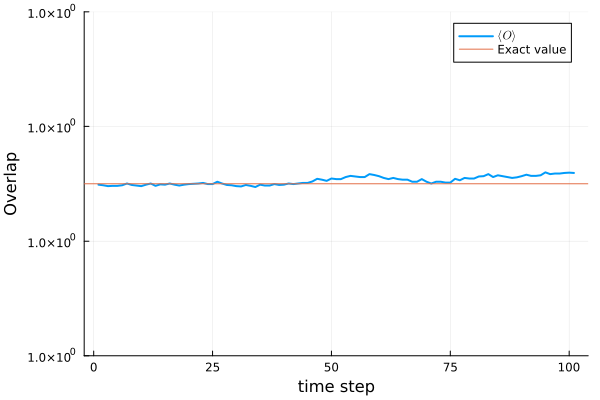

Average Overlap : 1.0000000000000016 ≈ 1


In [ ]:
overlap_values = result_id["overlap"]

dy = 1e-13
p = plot(overlap_values,
     xlabel="time step",
     ylabel="Overlap",
     label=L"\langle O \rangle",
     lw=2,
     ylims=(1-dy,1+dy))

hline!(p, [1], label="Exact value")
display(p)

println("Average Overlap : ", mean(overlap_values)," ≈ 1")

And the overlap $\langle \uparrow | \mathbb I | \uparrow \rangle \approx 1 \pm10^{-14}$.

---

## 1.4 Operator Entanglement

The bond dimension $\chi$ measures operator entanglement if the cutoff isn't too large.

If we divide the system into two parts: $A | B$ at idinces `bond` on the spin chain.

In [ ]:
bond = nqubits÷2 # we divide the system in the middle

4

We would like to know 'how far' an operator $\hat{O}(t)$ is from a product operator,
$$\hat O \approx O^A \otimes O^B$$

The operator can be rewritten as a matrix:

$$\hat{O} = \sum_\alpha s_\alpha A_\alpha \otimes B_\alpha$$

where:
- $s_\alpha =$  singular values
- $A_\alpha$ acts on A
- $B_\alpha$ acts on B

This is a Schmidt decomposition of the operator.

### Operator Entanglement Entropy

is useful to determine whether an operator can be approximated by a Matrix Product Operator with small bond dimension

$$S_{op} = - \sum_{\alpha } p_\alpha log(p_\alpha)$$

with
$$p_\alpha = \frac{s_\alpha^2}{\sum_\beta s_\beta^2}$$


In [ ]:
entropy = mpo.operator_entropy(IdMPO_t, bond)

-0.0

Identity can clearly be express as
$$Id = \mathbb I_2 \otimes \dots \otimes\mathbb I_2 \implies S(Id) = 0 $$


---

# 2. Verification of the correct implementation of the method (TFIM circuit)

In this part we gonna focus on a simple and controlled setting, a Transverse Field Ising Model circuit (with $g, h = 0$ we have $H_{MFIM} =H_{TFIM} = \sum_{\langle i,j \rangle} X_i X_j$) in order to validate the method and build intuition before moving to the real MFIM case.

## 2.1 Initialisation for the Matrix Product Operator method

In [ ]:
# TFIM circuit
nlayers = 150
TFIM_circuit = ct.mpo_compute_MFIM_circuit(nqubits, nlayers, τ, 0.0, 0.0) # with g, h = 0

println("Gates in the circuit : ", length(TFIM_circuit)*length(TFIM_circuit[1]))

Gates in the circuit : 1650


The observable to be propagated will be a local observable, $Z_2 = \mathbb I \otimes Z \otimes \mathbb I \dots \mathbb I$ (max link dim need to be 1).

In [ ]:
# observable
i = 2
ops = ["Id" for n in 1:nqubits]
ops[i] = "Z"
Z_i = MPO(sites, ops)
println("Max link dimension = ", maxlinkdim(Z_i))

Max link dimension = 1


For $Z_2$, we obtain $\chi = 1$ so this is indeed a local operator.

Let's see if the operator propagates correctly through the chain and if it remains local

---

## 2.2 Propagation with the MPO method

We try to see if the method is well implemented so let's check without any truncation.

In [ ]:
# Truncations (we want an exact result so no truncation)
cutoff = 0.
maxdim = 2^nqubits

256

We will verify our method by comparing the time-dependent overlap of a $\psi_0$ state ($\langle \psi_0 | \hat O(t) | \psi_0\rangle$) with the exact method.

In [ ]:
# propagation
Z_i_t, result_mpo = mpo.propagate_layerbylayer(TFIM_circuit, Z_i; cutoff, maxdim, bond)

# Itensor -> matrix
Zi_t_matrix = mpo.compute_matrix(Z_i_t, sites)

layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by mpo_functions.propagate_layerbylayer: 96.14078783988953 seconds
Contraction resulted in ITensor with 15 indices, which is greater
        than or equal to the ITensor order warning threshold 14.
        You can modify the threshold with macros like `@set_warn_order N`,
        `@reset_warn_order`, and `@disable_warn_order` or functions like
        `ITensors.set_warn_order(N::Int)`, `ITensors.reset_warn_order()`, and
        `ITensors.disable_warn_order()`.

Stacktrace:
  [1] _contract(A::ITensor, B::ITensor)
    @ ITensors ~/.julia/packages/ITensors/SDJ87/src/tensor_operations/tensor_algebra.jl:20
  [2] contract(A::ITensor, B::ITensor)
    @ ITensors ~/.julia/packages/ITensors/SDJ87/src/tensor_operations/tensor_algebra.jl

256×256 Matrix{ComplexF64}:
    0.0237935-2.80145e-15im  …   5.37612e-17+6.41648e-15im
 -1.06988e-15+5.14341e-15im      5.92087e-16+7.07529e-15im
   2.8559e-15-7.1e-15im          1.36823e-15+5.82323e-15im
  1.90062e-15+3.86399e-15im     -1.73724e-15+2.58889e-15im
  2.01676e-15+2.38705e-15im      4.15846e-15-3.22594e-15im
  1.86301e-15-1.42366e-15im  …   1.47855e-15-5.54106e-15im
 -2.22817e-15-5.63272e-15im      1.67882e-15-1.98695e-15im
  1.42986e-15+3.5118e-15im       6.18043e-15-1.50312e-15im
 -1.69266e-15+3.09383e-15im      6.68741e-15-1.28594e-15im
 -1.29344e-15+2.93362e-15im     -1.66961e-15+1.05054e-15im
 -1.89322e-15+1.71494e-15im  …   3.24942e-15+1.17356e-15im
 -3.76705e-15+1.91835e-15im      5.75248e-15-8.99781e-16im
  3.57303e-15-3.23639e-15im     -1.22805e-15-6.53591e-16im
             ⋮               ⋱              ⋮
  5.95317e-15-4.3847e-15im       4.30691e-15+1.75856e-15im
  3.67979e-15-3.87807e-15im  …  -1.42635e-16-8.41049e-16im
 -6.86252e-16-1.78785e-15im       3.7248e

In [ ]:
println("Max link dimension = ", maxlinkdim(Z_i_t))

Max link dimension = 256


Now, the operator isn't local.

---

## 2.3 Exact Method

In [ ]:
Z_i_exact = ext.get_Zi(nqubits, i)
circuit_exact = ct.exact_circuit_TFIM(nqubits, τ*2, nlayers)

Zi_t_exact, result_exact = ext.propagate_layerbylayer(circuit_exact, Z_i_exact; bond)

Zi_t_exact

layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 3.9970481395721436 seconds


256×256 Matrix{ComplexF64}:
    0.0237935+0.0im          …  9.30969e-16+0.0im
          0.0+0.0im                     0.0+0.0im
          0.0+0.0im                     0.0+0.0im
          0.0-9.9102e-16im              0.0+4.13317e-16im
          0.0+0.0im                     0.0+0.0im
  -1.9627e-15+0.0im          …  3.48028e-16+0.0im
          0.0+1.15747e-15im             0.0+6.00285e-16im
          0.0+0.0im                     0.0+0.0im
          0.0+0.0im                     0.0+0.0im
          0.0-2.71758e-16im             0.0-3.42182e-16im
 -1.47439e-15+0.0im          …  1.47447e-16+0.0im
          0.0+0.0im                     0.0+0.0im
          0.0+1.22864e-15im             0.0-9.2922e-16im
             ⋮               ⋱             ⋮
          0.0+0.0im                     0.0+0.0im
 -7.06002e-17+0.0im          …  5.33897e-16+0.0im
          0.0-1.22979e-16im             0.0+1.46778e-17im
          0.0+0.0im                     0.0+0.0im
          0.0+0.0im                   

---

## 2.4 Result

In [ ]:
is_close = isapprox(Zi_t_matrix, Zi_t_exact, rtol=1e-5)
println("Is the analytical calculation close to the Pauli propagation result?  ", is_close)

error_val = opnorm(Zi_t_matrix - Zi_t_exact)
println("with an error of :  ", error_val)

Is the analytical calculation close to the Pauli propagation result?  false
with an error of :  0.609621242204631


We obtain the same $Z_i(t_{final})$, barring a numerical error of $10^{-14}$ with $150$ evolution steps.

Numerical error is calculate with the LinearAlgebra.jl function, `opnorm(A)`, corresponding to the spectral norm :
$$||A||_2 = \sqrt{\lambda_{max} (A^\dagger A) } = \sigma_{max}(A) $$

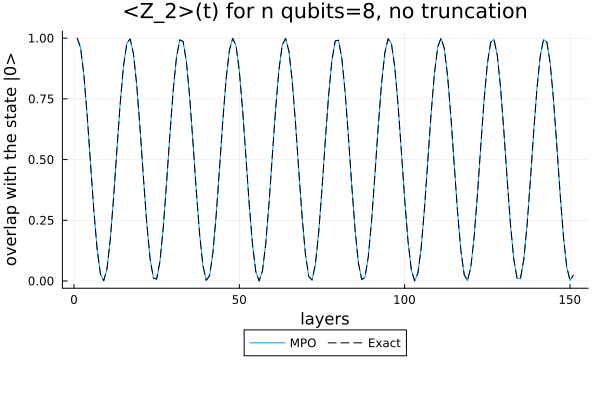

In [ ]:
overlap_mpo = result_mpo["overlap"]
overlap_exact = result_exact["overlap"]

p = plot(title="<Z_$i>(t) for n qubits=$nqubits, no truncation", xlabel="layers", ylabel="overlap with the state |0>")

plot!(p, overlap_mpo, label="MPO", line = (1, :solid))
plot!(p, overlap_exact, label="Exact", line = (1, :dash), color=:black)
plot!(legend=:outerbottom, legendcolumns=2)

display(p)

We obtain the same curve along the $150$ evolution steps.

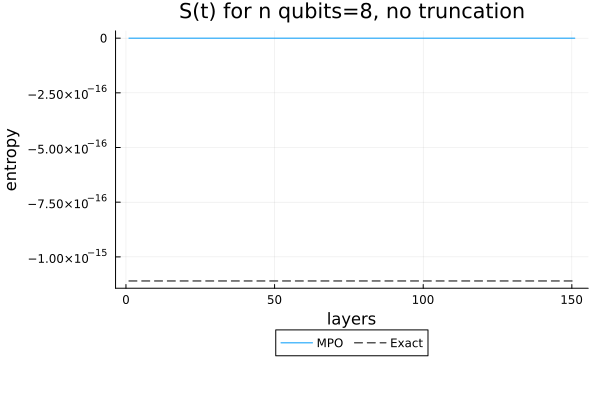

In [ ]:
entropy_mpo = result_mpo["S"]
entropy_exact = result_exact["S"]

p = plot(title="S(t) for n qubits=$nqubits, no truncation", xlabel="layers", ylabel="entropy")

plot!(p, entropy_mpo, label="MPO", line = (1, :solid))
plot!(p, entropy_exact, label="Exact", line = (1, :dash), color=:black)
plot!(legend=:outerbottom, legendcolumns=2)

display(p)

---

# 3. Truncations test

## 3.1 Max dimension

In [ ]:
cutoff = 1e-8
maxdim_list = [100, 200, 2^nqubits]

overlap_values, chi_values, S_values = Vector[], Vector[], Vector[]
for maxdim in maxdim_list
  println("---")
  Z_it, result = mpo.propagate_layerbylayer(MFIM_circuit, Z_i; cutoff, maxdim)
  push!(overlap_values, result["overlap"])
  push!(chi_values, result["maxlink"])
  push!(S_values, result["S"])
  println("Max link dimension at the end = ", maxlinkdim(Z_it))
  println("Max bond dim possible = ", maxdim)
end



---
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by mpo_functions.propagate_layerbylayer: 27.875319004058838 seconds
Max link dimension at the end = 100
Max bond dim possible = 100
---
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by mpo_functions.propagate_layerbylayer: 78.57884192466736 seconds
Max link dimension at the end = 200
Max bond dim possible = 200
---
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
l

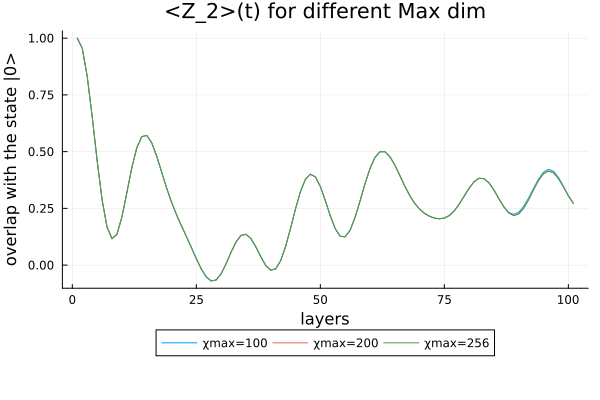

In [ ]:
p = plot(title="<Z_$i>(t) for different Max dim", xlabel="layers", ylabel="overlap with the state |0>")
for j in 1:length(maxdim_list)
  plot!(p, 1:length(overlap_values[j]), overlap_values[j], label="χmax=$(maxdim_list[j])")
plot!(legend=:outerbottom, legendcolumns=length(maxdim_list))
end

display(p)

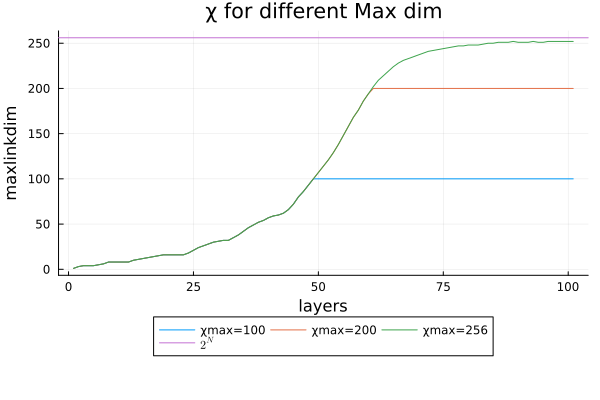

In [ ]:
p = plot(title="χ for different Max dim", xlabel="layers", ylabel="maxlinkdim")
for j in 1:length(maxdim_list)
  plot!(p, 1:length(chi_values[j]), chi_values[j], label="χmax=$(maxdim_list[j])")
  #hline!([maxdim_list[j]], label=maxdim_list[j])
end
hline!([2^nqubits], label=L"2^N")
plot!(legend=:outerbottom, legendcolumns=length(maxdim_list))

display(p)

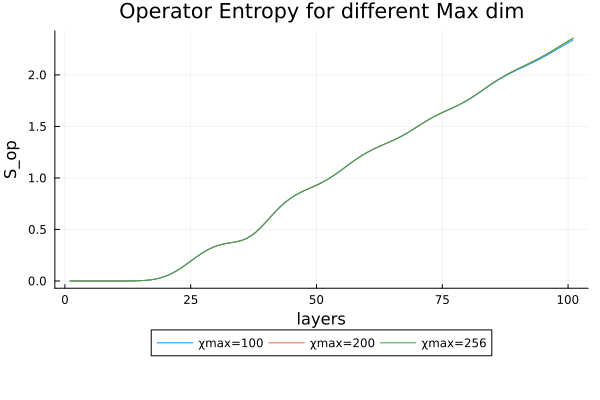

In [ ]:
p = plot(title="Operator Entropy for different Max dim", xlabel="layers", ylabel="S_op")
for j in 1:length(maxdim_list)
  plot!(p, 1:length(S_values[j]), S_values[j], label="χmax=$(maxdim_list[j])")
end
plot!(legend=:outerbottom, legendcolumns=length(maxdim_list))

display(p)


We observe an increase in the maximum bond dimension and a growth in $\chi$ due to operator entanglement caused by $X_jX_{j+1}$ in the Hamiltonian.

---

$$\chi \approx e^{S_{op}}? $$

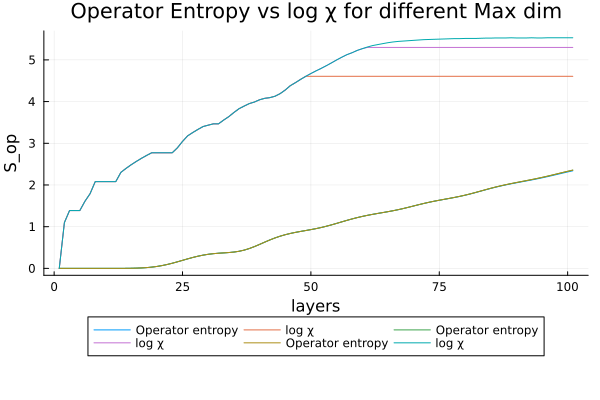

In [ ]:
p = plot(title="Operator Entropy vs log χ for different Max dim", xlabel="layers", ylabel="S_op")
for i in 1:length(maxdim_list)
  plot!(p, S_values[i],
      label="Operator entropy")

  plot!(p, log.(chi_values[i]),
        label="log χ")
end
plot!(legend=:outerbottom, legendcolumns=length(maxdim_list))
display(p)

---

## References

- [Julia documentation](https://docs.julialang.org/en/v1/)
- [ITensor documentation](https://docs.itensor.org/ITensors/stable/index.html)
- [Plots documentation](https://docs.juliaplots.org/stable/)
- [LinearAlgebra documentation](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/)
- [LaTeXStrings documentation](https://juliapackages.com/p/latexstrings)
- https://docs.juliaplots.org/dev/tutorial/
- https://www.phys.ens.psl.eu/~jacobsen/AMP21_Dubail.pdf
- https://tensornetwork.org/mps/algorithms/timeevo/tebd.html